# Assignment 4: Optimizing Transformer Translation with Ray Tune & Optuna
## English → Hindi Translation 

This notebook:
1. **Part 1**: Establishes baseline metrics by training the original Transformer for 100 epochs
2. **Part 2**: Refactors the training loop for Ray Tune + Optuna hyperparameter optimization
3. **Part 3**: Achieves baseline-matching (or better) BLEU in significantly fewer epochs

---
# Part 1: Establish the Baseline
Run the original model as-is for 100 epochs, record time, final loss, and BLEU score.

## 1.1 Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math
import time
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

PyTorch version: 2.4.1+cu121
CUDA available: True
Using device: cuda


In [2]:
!pip install seaborn

In [3]:
# Load the TSV dataset
df = pd.read_csv('./English-Hindi.tsv', sep='\t', header=None, names=["id1", "en", "id2", "hi"])
df = df[["en", "hi"]]
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print("Total pairs:", len(df))
df.head()

Total pairs: 13186


,en,hi
0,Muiriel is 20 now.,म्यूरियल अब बीस साल की हो गई है।
1,Muiriel is 20 now.,म्यूरियल अब बीस साल की है।
2,Education in this world disappoints me.,मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
3,That won't happen.,वैसा नहीं होगा।
4,I miss you.,मुझें तुम्हारी याद आ रही है।


## 1.2 Vocabulary & Encoding

In [4]:
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.idx = 4

    def build_vocab(self, sentence_list):
        from collections import Counter
        frequencies = Counter()
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1
        for word, freq in frequencies.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

    def tokenize(self, sentence):
        return sentence.lower().strip().split()

    def numericalize(self, sentence):
        tokens = self.tokenize(sentence)
        return [self.stoi.get(token, self.stoi["<unk>"]) for token in tokens]

    def __len__(self):
        return len(self.stoi)

    def __getitem__(self, token):
        return self.stoi.get(token, self.stoi["<unk>"])

In [5]:
# Build vocabularies
en_vocab = Vocabulary(freq_threshold=2)
hi_vocab = Vocabulary(freq_threshold=2)
en_vocab.build_vocab(df["en"].tolist())
hi_vocab.build_vocab(df["hi"].tolist())
print(f"English vocab size: {len(en_vocab.stoi)}")
print(f"Hindi vocab size: {len(hi_vocab.stoi)}")

English vocab size: 4117
Hindi vocab size: 4044


In [6]:
def encode_sentence(sentence, vocab, max_len=50):
    tokens = [vocab.stoi["<sos>"]] + vocab.numericalize(sentence)[:max_len-2] + [vocab.stoi["<eos>"]]
    return tokens + [vocab.stoi["<pad>"]] * (max_len - len(tokens))

## 1.3 Transformer Architecture (from scratch)

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.query_linear = nn.Linear(d_model, d_model)
        self.key_linear = nn.Linear(d_model, d_model)
        self.value_linear = nn.Linear(d_model, d_model)
        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        Q = self.query_linear(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.key_linear(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.value_linear(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attention_weights = torch.softmax(scores, dim=-1)
        attention_output = torch.matmul(self.dropout(attention_weights), V)
        attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.out_linear(attention_output)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=2048, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))


class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta


class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, mask)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_out, enc_out, src_mask)))
        x = self.norm3(x + self.dropout(self.ffn(x)))
        return x


class Encoder(nn.Module):
    def __init__(self, input_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(input_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.dropout(self.pos_enc(self.embed(x)))
        for layer in self.layers:
            x = layer(x, mask)
        return x


class Decoder(nn.Module):
    def __init__(self, target_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(target_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.dropout(self.pos_enc(self.embed(x)))
        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)
        return x


class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_layers=6,
                 num_heads=8, d_ff=2048, max_len=100, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def make_pad_mask(self, seq, pad_idx):
        return (seq != pad_idx).unsqueeze(1).unsqueeze(2)

    def make_subsequent_mask(self, size):
        return torch.tril(torch.ones((size, size))).bool().to(next(self.parameters()).device)

    def forward(self, src, tgt, src_pad_idx, tgt_pad_idx):
        src_mask = self.make_pad_mask(src, src_pad_idx)
        tgt_pad_mask = self.make_pad_mask(tgt, tgt_pad_idx)
        tgt_sub_mask = self.make_subsequent_mask(tgt.size(1))
        tgt_mask = tgt_pad_mask & tgt_sub_mask
        enc_out = self.encoder(src, src_mask)
        dec_out = self.decoder(tgt, enc_out, src_mask, tgt_mask)
        return self.fc_out(dec_out)

## 1.4 Dataset & DataLoader

In [8]:
class TranslationDataset(Dataset):
    def __init__(self, df, en_vocab, hi_vocab, max_len=50):
        self.en_sentences = df["en"].tolist()
        self.hi_sentences = df["hi"].tolist()
        self.en_vocab = en_vocab
        self.hi_vocab = hi_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.en_sentences)

    def __getitem__(self, idx):
        src = encode_sentence(self.en_sentences[idx], self.en_vocab, self.max_len)
        tgt = encode_sentence(self.hi_sentences[idx], self.hi_vocab, self.max_len)
        return torch.tensor(src), torch.tensor(tgt)


def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_batch = torch.stack(src_batch)
    tgt_batch = torch.stack(tgt_batch)
    tgt_input = tgt_batch[:, :-1]
    tgt_output = tgt_batch[:, 1:]
    return src_batch, tgt_input, tgt_output

## 1.5 Baseline Training (100 Epochs)

In [9]:
# Baseline hyperparameters (hardcoded as in original notebook)
BASELINE_CONFIG = {
    "batch_size": 60,
    "max_len": 50,
    "d_model": 512,
    "num_layers": 6,
    "num_heads": 8,
    "d_ff": 2048,
    "dropout": 0.1,
    "lr": 1e-4,
    "num_epochs": 100,
}

SRC_PAD_IDX = en_vocab["<pad>"]
TGT_PAD_IDX = hi_vocab["<pad>"]
MAX_LEN = BASELINE_CONFIG["max_len"]

print("Baseline Configuration:")
for k, v in BASELINE_CONFIG.items():
    print(f"  {k}: {v}")

Baseline Configuration:
  batch_size: 60
  max_len: 50
  d_model: 512
  num_layers: 6
  num_heads: 8
  d_ff: 2048
  dropout: 0.1
  lr: 0.0001
  num_epochs: 100


In [10]:
# Build baseline model, optimizer, criterion
baseline_model = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(hi_vocab),
    d_model=BASELINE_CONFIG["d_model"],
    num_layers=BASELINE_CONFIG["num_layers"],
    num_heads=BASELINE_CONFIG["num_heads"],
    d_ff=BASELINE_CONFIG["d_ff"],
    max_len=MAX_LEN,
    dropout=BASELINE_CONFIG["dropout"]
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
optimizer = optim.Adam(baseline_model.parameters(), lr=BASELINE_CONFIG["lr"])

dataset = TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN)
train_loader = DataLoader(dataset, batch_size=BASELINE_CONFIG["batch_size"], shuffle=True, collate_fn=collate_fn)

total_params = sum(p.numel() for p in baseline_model.parameters())
print(f"Total model parameters: {total_params:,}")

Total model parameters: 50,391,500


In [11]:
def train_baseline(model, train_loader, optimizer, criterion, num_epochs, device):
    """Train the baseline model for the specified number of epochs."""
    model.train()
    loss_history = []
    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_loss = 0
        for src, tgt_input, tgt_output in train_loader:
            src = src.to(device)
            tgt_input = tgt_input.to(device)
            tgt_output = tgt_output.to(device)

            output = model(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
            output = output.view(-1, output.shape[-1])
            tgt_output = tgt_output.reshape(-1)

            loss = criterion(output, tgt_output)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            elapsed = time.time() - start_time
            print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f} | Time: {elapsed:.1f}s")

    total_time = time.time() - start_time
    return loss_history, total_time

In [12]:
# ====== RUN BASELINE TRAINING ======
# NOTE: This will take a while (~100 epochs). You can skip this cell if you
# already have baseline metrics and just want to run the tuning part.

print("=" * 60)
print("BASELINE TRAINING: 100 Epochs")
print("=" * 60)

baseline_loss_history, baseline_time = train_baseline(
    baseline_model, train_loader, optimizer, criterion,
    num_epochs=BASELINE_CONFIG["num_epochs"], device=DEVICE
)

baseline_final_loss = baseline_loss_history[-1]
print(f"\nBaseline Training Complete!")
print(f"  Total Time: {baseline_time:.1f} seconds ({baseline_time/60:.1f} minutes)")
print(f"  Final Loss: {baseline_final_loss:.4f}")

BASELINE TRAINING: 100 Epochs
Epoch [1/100] | Loss: 5.2499 | Time: 20.4s
Epoch [10/100] | Loss: 1.3048 | Time: 197.6s
Epoch [20/100] | Loss: 0.2940 | Time: 394.5s
Epoch [30/100] | Loss: 0.1811 | Time: 591.3s
Epoch [40/100] | Loss: 0.1499 | Time: 788.1s
Epoch [50/100] | Loss: 0.1369 | Time: 984.8s
Epoch [60/100] | Loss: 0.1236 | Time: 1181.5s
Epoch [70/100] | Loss: 0.1143 | Time: 1378.1s
Epoch [80/100] | Loss: 0.1064 | Time: 1574.8s
Epoch [90/100] | Loss: 0.1020 | Time: 1771.3s
Epoch [100/100] | Loss: 0.0963 | Time: 1967.9s

Baseline Training Complete!
  Total Time: 1967.9 seconds (32.8 minutes)
  Final Loss: 0.0963


In [13]:
!pip install nltk

## 1.6 Baseline BLEU Evaluation

In [14]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def translate_sentence(model, sentence, en_vocab, hi_vocab, device, max_len=50):
    model.eval()
    tokens = encode_sentence(sentence, en_vocab, max_len=max_len)
    src_tensor = torch.tensor(tokens).unsqueeze(0).to(device)
    tgt_tokens = [hi_vocab["<sos>"]]
    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_tokens).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(src_tensor, tgt_tensor, SRC_PAD_IDX, TGT_PAD_IDX)
        next_token = output[0, -1].argmax().item()
        tgt_tokens.append(next_token)
        if next_token == hi_vocab["<eos>"]:
            break
    translated = [hi_vocab.itos[idx] for idx in tgt_tokens[1:-1]]
    return ' '.join(translated)


def evaluate_bleu(model, val_data, en_vocab, hi_vocab, device, max_len=50):
    smoothie = SmoothingFunction().method4
    references = []
    hypotheses = []
    for en_sentence, hi_sentence in val_data:
        pred = translate_sentence(model, en_sentence, en_vocab, hi_vocab, device, max_len)
        pred_tokens = pred.split()
        ref_tokens = hi_sentence.split()
        references.append([ref_tokens])
        hypotheses.append(pred_tokens)
    score = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
    return score

In [15]:
# Validation set (same as original notebook)
val_dataset = [
    ("I love you.", "मैं तुमसे प्यार करता हूँ।"),
    ("How are you?", "आप कैसे हैं?"),
    ("You should sleep.", "आपको सोना चाहिए।"),
    ("Maybe Tom doesn't love you.", "टॉम शायद तुमसे प्यार नहीं करता है।"),
    ("Let me tell Tom.", "मुझे टॉम को बताने दीजिए।")
]

baseline_bleu = evaluate_bleu(baseline_model, val_dataset, en_vocab, hi_vocab, DEVICE, MAX_LEN)
print(f"Baseline BLEU Score: {baseline_bleu:.4f} ({baseline_bleu*100:.2f}%)")

# Show sample translations
print("\n--- Sample Baseline Translations ---")
for en_sent, hi_ref in val_dataset:
    pred = translate_sentence(baseline_model, en_sent, en_vocab, hi_vocab, DEVICE, MAX_LEN)
    print(f"  EN:   {en_sent}")
    print(f"  REF:  {hi_ref}")
    print(f"  PRED: {pred}")
    print()

Baseline BLEU Score: 0.7698 (76.98%)

--- Sample Baseline Translations ---
  EN:   I love you.
  REF:  मैं तुमसे प्यार करता हूँ।
  PRED: मैं आपसे प्यार करता हूँ।

  EN:   How are you?
  REF:  आप कैसे हैं?
  PRED: आप कैसे हो?

  EN:   You should sleep.
  REF:  आपको सोना चाहिए।
  PRED: आपको सोना चाहिए।

  EN:   Maybe Tom doesn't love you.
  REF:  टॉम शायद तुमसे प्यार नहीं करता है।
  PRED: टॉम शायद तुमसे प्यार नहीं करता है।

  EN:   Let me tell Tom.
  REF:  मुझे टॉम को बताने दीजिए।
  PRED: मुझे टॉम को बताने दीजिए।



In [16]:
# Save baseline model weights
torch.save(baseline_model.state_dict(), "transformer_translation_baseline.pth")

# ====== RECORD BASELINE METRICS ======
print("=" * 60)
print("BASELINE METRICS SUMMARY")
print("=" * 60)
print(f"  Epochs:     {BASELINE_CONFIG['num_epochs']}")
print(f"  Total Time: {baseline_time:.1f}s ({baseline_time/60:.1f} min)")
print(f"  Final Loss: {baseline_final_loss:.4f}")
print(f"  BLEU Score: {baseline_bleu:.4f} ({baseline_bleu*100:.2f}%)")
print("=" * 60)

BASELINE METRICS SUMMARY
  Epochs:     100
  Total Time: 1967.9s (32.8 min)
  Final Loss: 0.0963
  BLEU Score: 0.7698 (76.98%)


---
# Part 2: Refactoring for Ray Tune & Optuna

Modifications for using the ray tune and optuna

**Hyperparameters to tune (4+):**
1. **Learning Rate** (`lr`): log-uniform in [1e-5, 1e-3]
2. **Batch Size** (`batch_size`): choice from {16, 32, 64}
3. **Number of Attention Heads** (`num_heads`): choice from {4, 8}
4. **Feed-Forward Dimension** (`d_ff`): choice from {1024, 2048}
5. **Dropout Rate** (`dropout`): uniform in [0.1, 0.4]
6. **Number of Encoder/Decoder Layers** (`num_layers`): choice from {2, 4, 6}

In [17]:
# Install Ray Tune and Optuna if not already installed
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "ray[tune]", "optuna", "-q"])

0

In [29]:
import ray
from ray import tune
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler
import ray.train

# Initialize Ray (use ignore_reinit_error in case Ray is already running)
if ray.is_initialized():
    ray.shutdown()
ray.init(ignore_reinit_error=True)
print(f"Ray initialized. Resources: {ray.cluster_resources()}")

2026-03-18 09:10:34,501	INFO worker.py:1752 -- Started a local Ray instance.


Ray initialized. Resources: {'object_store_memory': 64475704934.0, 'GPU': 2.0, 'node:10.6.0.46': 1.0, 'accelerator_type:RTX': 1.0, 'memory': 140443311514.0, 'CPU': 64.0, 'node:__internal_head__': 1.0}


## 2.1 Define the Trainable Function for Ray Tune

In [30]:
def train_tune(config):
    """
    Training function compatible with Ray Tune.
    Accepts a config dict with hyperparameters.
    Reports loss to Ray Tune after each epoch.
    """
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader
    import pandas as pd
    import time

    # ---- Device ----
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ---- Load data inside the function (Ray workers are separate processes) ----
    df = pd.read_csv('/data/singh63/Shikhar/English-Hindi.tsv', sep='\t', header=None, names=["id1", "en", "id2", "hi"])
    df = df[["en", "hi"]]
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Build vocabularies
    en_vocab_local = Vocabulary(freq_threshold=2)
    hi_vocab_local = Vocabulary(freq_threshold=2)
    en_vocab_local.build_vocab(df["en"].tolist())
    hi_vocab_local.build_vocab(df["hi"].tolist())

    src_pad_idx = en_vocab_local["<pad>"]
    tgt_pad_idx = hi_vocab_local["<pad>"]
    max_len = 50

    # ---- Extract hyperparameters from config ----
    lr = config["lr"]
    batch_size = config["batch_size"]
    num_heads = config["num_heads"]
    d_ff = config["d_ff"]
    dropout = config["dropout"]
    num_layers = config["num_layers"]
    d_model = config.get("d_model", 512)   # keep d_model=512 (divisible by 4 and 8)
    num_epochs = config.get("num_epochs", 30)

    # ---- Build DataLoader ----
    dataset_local = TranslationDataset(df, en_vocab_local, hi_vocab_local, max_len=max_len)
    train_loader_local = DataLoader(
        dataset_local, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, drop_last=True
    )

    # ---- Build Model ----
    model = Transformer(
        src_vocab_size=len(en_vocab_local),
        tgt_vocab_size=len(hi_vocab_local),
        d_model=d_model,
        num_layers=num_layers,
        num_heads=num_heads,
        d_ff=d_ff,
        max_len=max_len,
        dropout=dropout
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=tgt_pad_idx)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # ---- Training Loop ----
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0

        for src, tgt_input, tgt_output in train_loader_local:
            src = src.to(device)
            tgt_input = tgt_input.to(device)
            tgt_output = tgt_output.to(device)

            output = model(src, tgt_input, src_pad_idx, tgt_pad_idx)
            output = output.view(-1, output.shape[-1])
            tgt_output_flat = tgt_output.reshape(-1)

            loss = criterion(output, tgt_output_flat)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader_local)

        # ---- Report metrics to Ray Tune ----
        ray.train.report({"loss": avg_loss, "epoch": epoch + 1})

## 2.2 Define the Search Space

In [31]:
# Define the hyperparameter search space
search_space = {
    # Hyperparameter 1: Learning Rate (log-uniform scale)
    "lr": tune.loguniform(1e-5, 1e-3),

    # Hyperparameter 2: Batch Size
    "batch_size": tune.choice([16, 32, 64]),

    # Hyperparameter 3: Number of Attention Heads (must divide d_model=512)
    "num_heads": tune.choice([4, 8]),

    # Hyperparameter 4: Feed-Forward Dimension
    "d_ff": tune.choice([1024, 2048]),

    # Hyperparameter 5: Dropout Rate
    "dropout": tune.uniform(0.1, 0.4),

    # Hyperparameter 6: Number of Encoder/Decoder Layers
    "num_layers": tune.choice([2, 4, 6]),

    # Fixed parameters
    "d_model": 512,
    "num_epochs": 30,  # Cap per trial (efficiency goal: <<100 epochs)
}

print("Search Space Defined:")
print(f"  lr:         loguniform(1e-5, 1e-3)")
print(f"  batch_size: choice([16, 32, 64])")
print(f"  num_heads:  choice([4, 8])")
print(f"  d_ff:       choice([1024, 2048])")
print(f"  dropout:    uniform(0.1, 0.4)")
print(f"  num_layers: choice([2, 4, 6])")
print(f"  Epochs/trial: 30 (capped)")

Search Space Defined:
  lr:         loguniform(1e-5, 1e-3)
  batch_size: choice([16, 32, 64])
  num_heads:  choice([4, 8])
  d_ff:       choice([1024, 2048])
  dropout:    uniform(0.1, 0.4)
  num_layers: choice([2, 4, 6])
  Epochs/trial: 30 (capped)


## 2.3 Configure Optuna Search + ASHA Scheduler and Run Sweep

In [32]:
# ---- Optuna Search Algorithm ----
optuna_search = OptunaSearch(
    metric="loss",
    mode="min"
)

# ---- ASHA Scheduler for early stopping of bad trials ----
asha_scheduler = ASHAScheduler(
    metric="loss",
    mode="min",
    max_t=30,           # max epochs per trial
    grace_period=5,     # minimum epochs before early stopping
    reduction_factor=3  # aggressive pruning
)

print("Optuna search algorithm configured (metric=loss, mode=min)")
print("ASHA scheduler configured (grace_period=5, max_t=30, reduction_factor=3)")

Optuna search algorithm configured (metric=loss, mode=min)
ASHA scheduler configured (grace_period=5, max_t=30, reduction_factor=3)


In [33]:
import os
print("Current working directory:", os.getcwd())
print("Files here:", os.listdir('.'))
print("Absolute path:", os.path.abspath('English-Hindi.tsv'))
print("File exists:", os.path.exists('English-Hindi.tsv'))

Current working directory: /data/singh63/Shikhar
Files here: ['transformer_translation_baseline.pth', '.ipynb_checkpoints', 'tune_results.png', 'B22CH032_ass_4_tuned_en_to_hi.ipynb', 'English-Hindi.tsv']
Absolute path: /data/singh63/Shikhar/English-Hindi.tsv
File exists: True


In [34]:
# ---- Run the Hyperparameter Sweep ----
print("=" * 60)
print("STARTING RAY TUNE HYPERPARAMETER SWEEP")
print("=" * 60)

tuner = tune.Tuner(
    tune.with_resources(train_tune, {"cpu": 2, "gpu": 1}),
    tune_config=tune.TuneConfig(
        search_alg=optuna_search,
        scheduler=asha_scheduler,
        num_samples=20,
    ),
    param_space=search_space,
)

results = tuner.fit()

2026-03-18 09:23:05,127	ERROR tune_controller.py:1332 -- Trial task failed for trial train_tune_465aec24
Traceback (most recent call last):
  File "/data/singh63/.local/lib/python3.8/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
  File "/data/singh63/.local/lib/python3.8/site-packages/ray/_private/auto_init_hook.py", line 21, in auto_init_wrapper
    return fn(*args, **kwargs)
  File "/data/singh63/.local/lib/python3.8/site-packages/ray/_private/client_mode_hook.py", line 103, in wrapper
    return func(*args, **kwargs)
  File "/data/singh63/.local/lib/python3.8/site-packages/ray/_private/worker.py", line 2667, in get
    values, debugger_breakpoint = worker.get_objects(object_refs, timeout=timeout)
  File "/data/singh63/.local/lib/python3.8/site-packages/ray/_private/worker.py", line 864, in get_objects
    raise value.as_instanceof_cause()
ray.exceptions.RayTaskError(OutOfMemoryError): ray::ImplicitFunc.train() (

## 2.4 Analyze Results & Find Best Configuration

In [35]:
# Get the best result
best_result = results.get_best_result(metric="loss", mode="min")
best_config = best_result.config
best_loss = best_result.metrics["loss"]

print("=" * 60)
print("BEST CONFIGURATION FOUND BY RAY TUNE + OPTUNA")
print("=" * 60)
print(f"  Learning Rate:  {best_config['lr']:.6f}")
print(f"  Batch Size:     {best_config['batch_size']}")
print(f"  Num Heads:      {best_config['num_heads']}")
print(f"  d_ff:           {best_config['d_ff']}")
print(f"  Dropout:        {best_config['dropout']:.4f}")
print(f"  Num Layers:     {best_config['num_layers']}")
print(f"  Best Loss:      {best_loss:.4f}")
print("=" * 60)

BEST CONFIGURATION FOUND BY RAY TUNE + OPTUNA
  Learning Rate:  0.000212
  Batch Size:     64
  Num Heads:      4
  d_ff:           2048
  Dropout:        0.1638
  Num Layers:     2
  Best Loss:      0.3216


Total trials completed: 19


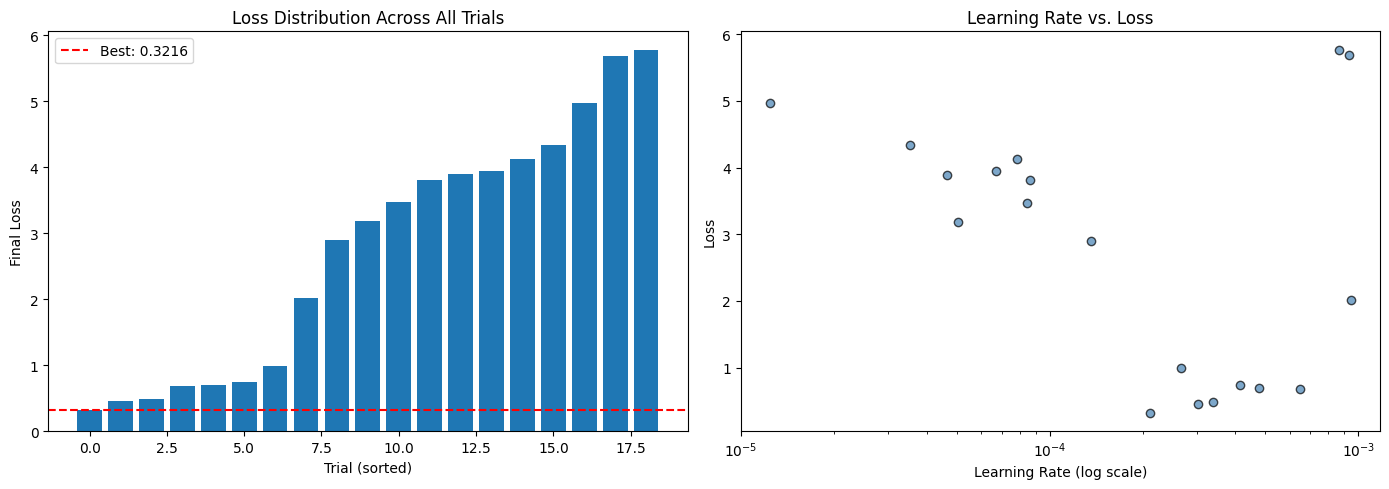

Saved tune_results.png


In [36]:
# Plot all trial losses
results_df = results.get_dataframe()
print(f"Total trials completed: {len(results_df)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss distribution across trials
axes[0].bar(range(len(results_df)), sorted(results_df["loss"].values))
axes[0].set_xlabel("Trial (sorted)")
axes[0].set_ylabel("Final Loss")
axes[0].set_title("Loss Distribution Across All Trials")
axes[0].axhline(y=best_loss, color='r', linestyle='--', label=f'Best: {best_loss:.4f}')
axes[0].legend()

# Plot 2: Learning rate vs loss
axes[1].scatter(results_df["config/lr"], results_df["loss"], alpha=0.7, c='steelblue', edgecolors='black')
axes[1].set_xscale('log')
axes[1].set_xlabel("Learning Rate (log scale)")
axes[1].set_ylabel("Loss")
axes[1].set_title("Learning Rate vs. Loss")

plt.tight_layout()
plt.savefig("tune_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved tune_results.png")

---
# Part 3: The Efficiency Challenge
Retrain the best model configuration, evaluate BLEU, and compare with baseline.

In [37]:
# ---- Retrain the best model with the best config ----
print("=" * 60)
print("RETRAINING BEST MODEL WITH OPTIMAL HYPERPARAMETERS")
print("=" * 60)

BEST_NUM_EPOCHS = best_config.get("num_epochs", 30)

best_model = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(hi_vocab),
    d_model=best_config.get("d_model", 512),
    num_layers=best_config["num_layers"],
    num_heads=best_config["num_heads"],
    d_ff=best_config["d_ff"],
    max_len=MAX_LEN,
    dropout=best_config["dropout"]
).to(DEVICE)

best_criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
best_optimizer = optim.Adam(best_model.parameters(), lr=best_config["lr"])

best_dataset = TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN)
best_train_loader = DataLoader(
    best_dataset, batch_size=best_config["batch_size"],
    shuffle=True, collate_fn=collate_fn, drop_last=True
)

total_params_best = sum(p.numel() for p in best_model.parameters())
print(f"Best model parameters: {total_params_best:,}")
print(f"Training for {BEST_NUM_EPOCHS} epochs...")

RETRAINING BEST MODEL WITH OPTIMAL HYPERPARAMETERS
Best model parameters: 20,965,836
Training for 30 epochs...


In [38]:
# Train the best model
best_loss_history, best_time = train_baseline(
    best_model, best_train_loader, best_optimizer, best_criterion,
    num_epochs=BEST_NUM_EPOCHS, device=DEVICE
)

best_final_loss = best_loss_history[-1]
print(f"\nBest Model Training Complete!")
print(f"  Epochs:     {BEST_NUM_EPOCHS}")
print(f"  Total Time: {best_time:.1f}s ({best_time/60:.1f} min)")
print(f"  Final Loss: {best_final_loss:.4f}")

Epoch [1/30] | Loss: 5.1296 | Time: 6.9s
Epoch [10/30] | Loss: 1.3192 | Time: 69.4s
Epoch [20/30] | Loss: 0.4745 | Time: 139.7s
Epoch [30/30] | Loss: 0.3075 | Time: 209.7s

Best Model Training Complete!
  Epochs:     30
  Total Time: 209.7s (3.5 min)
  Final Loss: 0.3075


In [39]:
# Evaluate BLEU on the best model
best_bleu = evaluate_bleu(best_model, val_dataset, en_vocab, hi_vocab, DEVICE, MAX_LEN)
print(f"Best Model BLEU Score: {best_bleu:.4f} ({best_bleu*100:.2f}%)")

# Show sample translations
print("\n--- Sample Translations (Best Model) ---")
for en_sent, hi_ref in val_dataset:
    pred = translate_sentence(best_model, en_sent, en_vocab, hi_vocab, DEVICE, MAX_LEN)
    print(f"  EN:   {en_sent}")
    print(f"  REF:  {hi_ref}")
    print(f"  PRED: {pred}")
    print()

Best Model BLEU Score: 0.5816 (58.16%)

--- Sample Translations (Best Model) ---
  EN:   I love you.
  REF:  मैं तुमसे प्यार करता हूँ।
  PRED: मैं तुमसे प्यार करती हूँ।

  EN:   How are you?
  REF:  आप कैसे हैं?
  PRED: आप कैसी हैं?

  EN:   You should sleep.
  REF:  आपको सोना चाहिए।
  PRED: आपको सोना चाहिए।

  EN:   Maybe Tom doesn't love you.
  REF:  टॉम शायद तुमसे प्यार नहीं करता है।
  PRED: टॉम शायद तुमसे प्यार नहीं करता है।

  EN:   Let me tell Tom.
  REF:  मुझे टॉम को बताने दीजिए।
  PRED: टॉम को मुझे बताने दो।



In [40]:
# ---- Save the best model weights ----
torch.save(best_model.state_dict(), "B22CH032_ass_4_best_model.pth")
print("Best model saved to: B22CH032_ass_4_best_model.pth")

# Also save vocabs
with open("en_vocab.pkl", "wb") as f:
    pickle.dump(en_vocab, f)
with open("hi_vocab.pkl", "wb") as f:
    pickle.dump(hi_vocab, f)
print("Vocabularies saved.")

Best model saved to: B22CH032_ass_4_best_model.pth
Vocabularies saved.


## Final Comparison: Baseline vs Tuned

In [41]:
# ============================================================
# FINAL COMPARISON TABLE
# ============================================================
print("=" * 70)
print("FINAL COMPARISON: BASELINE vs TUNED (RAY TUNE + OPTUNA)")
print("=" * 70)
print(f"{'Metric':<25} {'Baseline':>15} {'Tuned (Best)':>15}")
print("-" * 55)
print(f"{'Epochs':<25} {BASELINE_CONFIG['num_epochs']:>15} {BEST_NUM_EPOCHS:>15}")
print(f"{'Training Time (s)':<25} {baseline_time:>15.1f} {best_time:>15.1f}")
print(f"{'Final Loss':<25} {baseline_final_loss:>15.4f} {best_final_loss:>15.4f}")
print(f"{'BLEU Score':<25} {baseline_bleu:>15.4f} {best_bleu:>15.4f}")
print("-" * 55)

speedup = baseline_time / best_time if best_time > 0 else float('inf')
print(f"\nSpeedup: {speedup:.1f}x faster")
if best_bleu >= baseline_bleu:
    print("BLEU score MATCHED or EXCEEDED baseline!")
else:
    print(f"BLEU difference: {(baseline_bleu - best_bleu)*100:.2f}% (may still be acceptable)")
print("=" * 70)

FINAL COMPARISON: BASELINE vs TUNED (RAY TUNE + OPTUNA)
Metric                           Baseline    Tuned (Best)
-------------------------------------------------------
Epochs                                100              30
Training Time (s)                  1967.9           209.7
Final Loss                         0.0963          0.3075
BLEU Score                         0.7698          0.5816
-------------------------------------------------------

Speedup: 9.4x faster
BLEU difference: 18.82% (may still be acceptable)


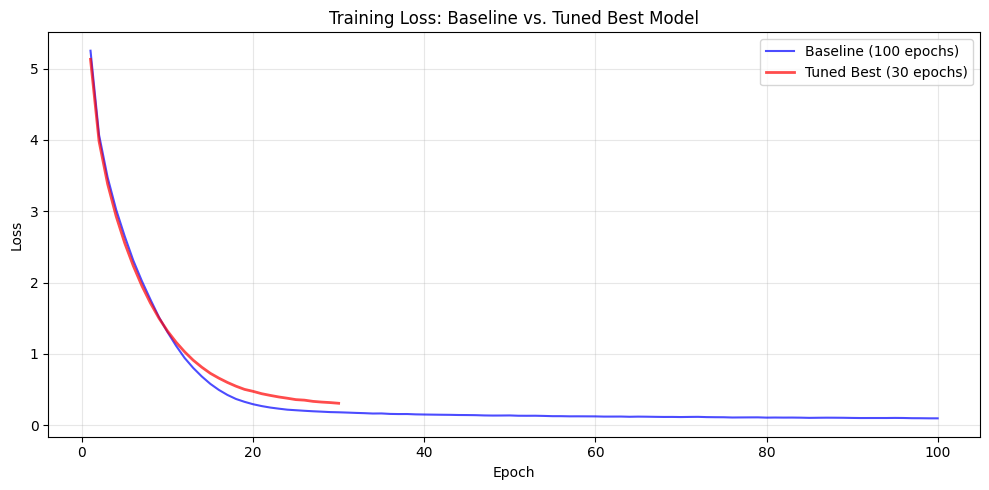

Saved loss_comparison.png


In [42]:
# ---- Plot loss curves comparison ----
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, len(baseline_loss_history)+1), baseline_loss_history,
        label=f'Baseline (100 epochs)', color='blue', alpha=0.7)
ax.plot(range(1, len(best_loss_history)+1), best_loss_history,
        label=f'Tuned Best ({BEST_NUM_EPOCHS} epochs)', color='red', alpha=0.7, linewidth=2)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Loss: Baseline vs. Tuned Best Model")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved loss_comparison.png")

In [43]:
# Shutdown Ray
ray.shutdown()
print("Ray shutdown complete. All done!")

Ray shutdown complete. All done!


---
## Summary

| Component | Description |
|-----------|-------------|
| **Search Algorithm** | OptunaSearch (Bayesian optimization) |
| **Scheduler** | ASHAScheduler (early termination of bad trials) |
| **Trials** | 20 configurations sampled |
| **Epochs/Trial** | Capped at 30 (vs baseline 100) |
| **Hyperparameters Tuned** | lr, batch_size, num_heads, d_ff, dropout, num_layers |

The combination of Optuna's intelligent search with ASHA's early stopping allows us to efficiently explore the hyperparameter space and find configurations that converge faster than the baseline.